In [1]:
# Import libaries
import ast
import random
import re
from collections import Counter
from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn import metrics, model_selection, preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

# Set directories
dir_data = Path("data")

/scratch/lustre/home/hpc_gretadovi/propaganda_technique_classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### parse_raw_data

In [2]:
df = pd.read_csv(dir_data / "concatenated.csv")
df = df.loc[:, ["annotation_id", "content", "label"]]

# Remove na
df.dropna(inplace=True)

fragments = []
for index, row in df.iterrows():
    content: str = row["content"] # format: string
    id: int = row["annotation_id"]
    labels_list: list = ast.literal_eval(row["label"]) # format: list
    for dictionary in labels_list:
        start = dictionary.get("start")
        end = dictionary.get("end")
        labels = dictionary.get("labels") 
        labels = "".join(labels)
        fragments.append((id, content[start:end+1], labels)) 

new_df = pd.DataFrame(data=fragments, columns=["id", "fragment", "label"])

# unique propaganda techniques
techniques = pd.unique(new_df["label"])
new_df = new_df[new_df['label'] != ""]

# Save
new_df = new_df[new_df["fragment"].str.strip() != ""] # removing empty fragment strings
new_df.to_csv(dir_data / "prepared_data.csv", index=False)

### eda

/tmp/slurm-hpc_gretadovi-244185/ipykernel_952378/910316596.py:185: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  singlelabel_df["label"] = singlelabel_df["labels"].apply(lambda x: np.array(x).astype(int).item())


<Axes: ylabel='label'>

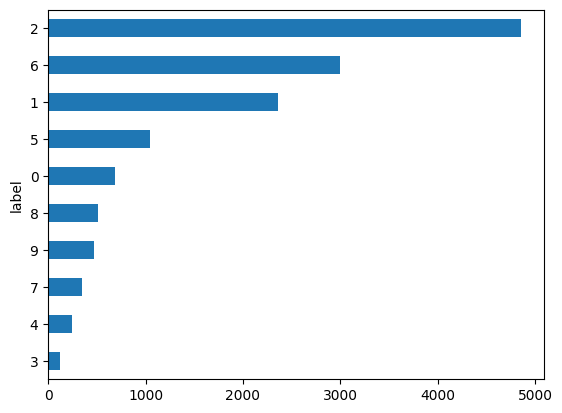

In [3]:
new_df = pd.read_csv(dir_data / "prepared_data.csv")

def prettify_label(label):
    words = re.findall(r'[A-Z]?[a-z]+', label)
    words = [word.capitalize() for word in words if word]
    return ' '.join(words)

new_df['pretty_label'] = new_df['label'].apply(prettify_label)
new_df = new_df[new_df["fragment"].str.strip() != ""]

def label_encoder(df: pd.DataFrame, label_column: str):
    encoder = preprocessing.LabelEncoder()
    df["encoded_labels"] = encoder.fit_transform(df[label_column])
    return df

new_df["pretty_label"].value_counts(ascending=True).plot.barh()
# plt.title("Propaganda technique distribution")
# plt.ylabel("")
# plt.show()

# Fragment length in words
fragment_lengths_words = [len(x.split()) for x in new_df["fragment"]]

# 99th percentile of fragment lengths
percentile99 = int(np.percentile(fragment_lengths_words, 99))
# print("99th percentile of fragment lengths", percentile99)

# plt.hist(fragment_lengths_words, range=(0, percentile99), bins=30, edgecolor="black")
# plt.axvline(x=np.mean(fragment_lengths_words), c="navy", ls="--")
# plt.xlabel("Fragment length in words")
# plt.ylabel("Distribution")
# plt.title("Distribution of fragment lengths (in words)")
# plt.show()
# print("Shortest fragment (words) length:", min(fragment_lengths_words))
# print("Longest fragment (words) length:", max(fragment_lengths_words))
# print("Average fragment (words) length:", np.mean(fragment_lengths_words))
# print("Standard deviation of fragment (words) length:", np.std(fragment_lengths_words))

# check how many labels one text has
ids = pd.unique(new_df["id"])
num_labs = []
num_fragments_per_article = []
for id in ids:
    df_id = new_df[new_df["id"] == id]
    num_fragments_per_article.append(len(df_id))
    unique_labs = pd.unique(df_id["label"])
    num_labs.append(len(unique_labs))

# plt.hist(num_labs, bins=np.arange(0,10)+0.5, range=[0, 10], edgecolor="black")
# plt.axvline(x=np.mean(num_labs), c="navy", ls="--")
# plt.xlabel("Number of techniques per article")
# plt.ylabel("Number of articles")
# plt.title("Distribution of propaganda techniques per article")
# plt.show()
# print("Average number of techniques per article", np.mean(num_labs))
# print("Min number of techniques per article", np.min(num_labs))
# print("Max number of techniques per article", np.max(num_labs))

percentile99 = int(np.percentile(num_fragments_per_article, 99))
# print("99th percentile of fragment lengths", percentile99)
# plt.hist(num_fragments_per_article, bins=20, range=[0, percentile99], edgecolor="black")
# plt.axvline(x=np.mean(num_fragments_per_article), c="navy", ls="--")
# plt.xlabel("Number of fragments per article")
# plt.ylabel("Number of articles")
# plt.title("Distribution of propaganda fragments per article")
# plt.show()
# print("Average number of fragments per article", np.mean(num_fragments_per_article))
# print("Min number of fragments per article", np.min(num_fragments_per_article))
# print("Max number of fragments per article", np.max(num_fragments_per_article))

new_df["words_per_fragment"] = new_df["fragment"].str.split().apply(len)
# new_df.boxplot("words_per_fragment", by="pretty_label", grid=False,
#                   showfliers=False, color="black", vert=False)
# plt.suptitle("")
# plt.title("Fragment lengths")
# plt.xlabel("")
# plt.ylabel("")
# plt.show()

# get ids, spans, fragments and labels. 
df = pd.read_csv(dir_data / "concatenated.csv")
df = df.loc[:, ["annotation_id", "content", "label"]]
df.dropna(inplace=True)

fragments = []
for index, row in df.iterrows():
    content: str = row["content"] # format: string
    id: int = row["annotation_id"]
    labels_list: list = ast.literal_eval(row["label"]) # format: list
    for dictionary in labels_list:
        start = dictionary.get("start")
        end = dictionary.get("end")
        labels = dictionary.get("labels")

        labels = "".join(labels)
        fragments.append((id, content[start:end], labels, start, end))
# print(len(fragments))

new_df = pd.DataFrame(data=fragments, columns=["id", "fragment", "label", "start", "end"])

# print(new_df.shape)
new_df = new_df[new_df["fragment"].str.strip() != ""] # removing empty fragment strings
new_df = new_df[new_df["label"] != ""] # removing empty labels
# print(new_df.shape)

new_df = label_encoder(new_df, "label")
# print(new_df.head())
new_df.to_csv(dir_data / "data_start_stop.csv", index=False)

# from collections import Counter
# print(Counter(new_df["label"]))
# Counter(new_df["encoded_labels"])

# FIND EXACT MATCH

multilabel = []
only_multilabel = []
ids = pd.unique(new_df["id"])
for id in ids:
    id_df: pd.DataFrame = new_df.loc[new_df["id"] == id]
    
    checked_spans = set()

    for i in range(len(id_df)):
        exact_match_labels = []
        span_start = id_df.iloc[i, 3]
        span_end = id_df.iloc[i, 4]
        span_label = id_df.iloc[i, 5]
        exact_match_labels.append(span_label)

        span_id = (id, span_start, span_end)

        if span_id in checked_spans:
            continue
        checked_spans.add(span_id)
        for j in range(i+1, len(id_df)):
            compare_span_start = id_df.iloc[j, 3]
            compare_span_end = id_df.iloc[j, 4]
            compare_span_label = id_df.iloc[j, 5]

            if span_start == compare_span_start and span_end == compare_span_end:
                if span_label != compare_span_label:
                    exact_match_labels.append(compare_span_label)
        if len(exact_match_labels) > 1:
            only_multilabel.append((id, id_df.iloc[i, 1], exact_match_labels))
        multilabel.append((id, id_df.iloc[i, 1], exact_match_labels))


# print("Multilabel dataset:")
# print(len(multilabel))

# print("ONLY Multilabel dataset:")
# print(len(only_multilabel))


multilabel_df = pd.DataFrame(multilabel, columns=["id", "fragment", "labels"])
multilabel_df.to_csv(dir_data / "multilabel.csv", index=False)

only_multilabel_df = pd.DataFrame(only_multilabel, columns=["id", "fragment", "labels"])
list_labels = only_multilabel_df["labels"].to_list()
matrix = np.zeros(shape=(10, 10))
for i in range(len(list_labels)):
    lst = list_labels[i]
    if len(lst) == 2:
        matrix[lst[0]][lst[1]] += 1
        matrix[lst[1]][lst[0]] += 1
    else:
        matrix[lst[0]][lst[1]] += 1
        matrix[lst[1]][lst[0]] += 1
        matrix[lst[0]][lst[2]] += 1
        matrix[lst[2]][lst[0]] += 1
        matrix[lst[1]][lst[2]] += 1
        matrix[lst[2]][lst[1]] += 1


df_matrix = pd.DataFrame(matrix, columns=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], index=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

# techs = ['Appeal To Authority', 'Doubt', 'Emotional Expression', 'Following Behind','Reductio Ad Hitlerum', 'Repetition', 'Simplification',  'Uncertainty', 'Waving The Flag', 'Whataboutism/RedHerring/StrawMan', ]
# sns.heatmap(df_matrix, cmap="Blues", xticklabels=techs, yticklabels=techs)
# plt.title("Co-occurring techniques")
# plt.show()
# df_matrix

singlelabel_df = multilabel_df[multilabel_df["labels"].map(len) == 1]
singlelabel_df["label"] = singlelabel_df["labels"].apply(lambda x: np.array(x).astype(int).item())
singlelabel_df.to_csv(dir_data / "single_label.csv", index=False)

singlelabel_df["label"].value_counts(ascending=True).plot.barh()
# plt.title("Propaganda technique distribution")
# plt.ylabel("")
# plt.show()

# Counter(singlelabel_df["label"])

### plm_finetuning

In [4]:
def display_cm(confusion_matrix):
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
    cm_display.plot()
    plt.show()


def calculate_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)
    return accuracy


def train_transformer_with_weights(input: pd.Series,
                      label: pd.Series,
                      input_seed : int,
                      model_name: str,
                      saved_model_name: str,
                      class_weights_tensor,
                      num_labels=10,
                      max_length=512,
                      val_size=0.1,
                      batch_size=16,
                      epochs=2,
                      learning_rate=2e-5):
    # Set seed
    # seed = 100
    seed = input_seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    model.to(device)

    # Encode
    encodings = tokenizer.batch_encode_plus(
        input.to_list(),
        max_length=max_length, # NOTE: choose "max_length" according to input sequence length distribution - see if it affects results
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encodings["input_ids"]
    attention_masks = encodings["attention_mask"]
    labels = torch.tensor(label.values)

    # Train and validation Dataloaders

    train_ids, val_ids, train_masks, val_masks, train_labels, val_labels = train_test_split(
        input_ids,
        attention_masks,
        labels,
        test_size=val_size,
        random_state=seed) # NOTE: Check whether shuffle and stratify changes results?

    train_data = TensorDataset(train_ids, train_masks, train_labels)
    val_data = TensorDataset(val_ids, val_masks, val_labels)
    g = torch.Generator()
    g.manual_seed(seed)
    train_dataloader = DataLoader(train_data, shuffle=True, batch_size=batch_size, generator=g) # NOTE: Check whether shuffle and batch changes results?
    val_dataloader = DataLoader(val_data, batch_size=batch_size)

    # Optimizer, loss function, scheduler
    # Schedulers are designed to gradually decrease the learning rate as the training continues
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    training_steps = epochs * len(train_dataloader)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * training_steps), num_training_steps=training_steps)

    # Training

    graph_train_loss = []
    graph_train_accuracy = []
    graph_val_loss = []
    graph_val_accuracy = []
    graph_val_f1 = []
    class_weight_tensor = class_weights_tensor.to(device)
    loss_function = torch.nn.CrossEntropyLoss(weight=class_weight_tensor)
    for epoch in range(epochs):
        t1 = time()
        model.train() # train mode
        training_loss = 0
        training_accuracy = 0
        
        for batch in train_dataloader:
            batch_input_ids = batch[0].to(device)
            batch_attention_mask = batch[1].to(device)
            batch_labels = batch[2].to(device)

            model.zero_grad() # reset the calculated gradients from the previous iteration of this loop

            outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
            logits = outputs.logits
            
            loss = loss_function(logits, batch_labels)
        
            training_loss += loss.item() # extract the float value using the item method
            loss.backward() # Perform a backward pass of the model and propagate the loss through the classifier head
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Clip the gradients to be no larger than 1.0 so the model does not suffer from the exploding gradients problem.
            optimizer.step() # call optimizer to make a steo in the direction of the error
            scheduler.step()
            training_accuracy += calculate_accuracy(logits.detach().cpu().numpy(), batch_labels.cpu().numpy())

        average_train_loss = training_loss / len(train_dataloader)
        average_train_accuracy = training_accuracy / len(train_dataloader)
        t2 = time()
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Average training loss: {average_train_loss:.4f}, average training accuracy: {average_train_accuracy:.4f}")
        print("Training time:", (t2-t1)/60)
        graph_train_loss.append(average_train_loss)
        graph_train_accuracy.append(average_train_accuracy)

        # Save model - doing checkpointing
        output_dir = f"saved_model_{saved_model_name}_epoch{epoch+1}_{seed}"
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True)
        model.save_pretrained(output_dir)
        tokenizer.save_pretrained(output_dir)

        # Validation
        model.eval()
        val_loss = 0
        val_accuracy = 0
        true_labels = []
        predictions = []

        with torch.no_grad():
            for batch in val_dataloader:
                batch_input_ids = batch[0].to(device)
                batch_attention_mask = batch[1].to(device)
                batch_labels = batch[2].to(device)
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask, labels=batch_labels)
                loss = outputs.loss
                logits = outputs.logits
                val_loss += loss.item()
                val_accuracy += calculate_accuracy(logits.detach().cpu().numpy(), batch_labels.cpu().numpy())

                preds = torch.argmax(logits, dim=1)
                true_labels.extend(batch_labels.cpu().numpy())
                predictions.extend(preds.cpu().numpy())

        average_val_accuracy = val_accuracy / len(val_dataloader)
        average_val_loss = val_loss / len(val_dataloader)
        f1score_val = metrics.f1_score(true_labels, predictions, average="macro")
        t3 = time()

        print(f"Avg val loss: {average_val_loss:.4f}, avg val accuracy: {average_val_accuracy:.4f}, f1 val (macro): {f1score_val}")
        print("Total epoch time", (t3-t1)/60)

        graph_val_loss.append(average_val_loss)
        graph_val_accuracy.append(average_val_accuracy)
        graph_val_f1.append(f1score_val)
        
    df = pd.DataFrame({"epochs": pd.Series(range(1, epochs+1)),
                       'train_loss': pd.Series(graph_train_loss), 
                       'val_loss': pd.Series(graph_val_loss),
                      "train_accuracy": pd.Series(graph_train_accuracy),
                      "val_accuracy": pd.Series(graph_val_accuracy),
                      "val_f1": pd.Series(graph_val_f1)})
    df.to_csv(f"./{saved_model_name}_train_val_metrics.csv", index=False)


    plt.plot(range(1, epochs+1), graph_train_accuracy, label="Training accuracy")
    plt.plot(range(1, epochs+1), graph_val_accuracy, label="Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()

    plt.plot(range(1, epochs+1), graph_val_f1, label="Validation F1 score")
    plt.title("Validation F1 score")
    plt.xlabel("Epochs")
    plt.ylabel("F1")
    plt.legend(loc='best')
    plt.show()

    return model, tokenizer


# Predict on test set
def evaluate_model(inputs, label, model, tokenizer, max_length=512, batch_size=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    encodings = tokenizer.batch_encode_plus(
        inputs.to_list(),
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encodings["input_ids"]
    attention_masks = encodings["attention_mask"]
    labels = torch.tensor(label.values)
    test_data = TensorDataset(input_ids, attention_masks, labels)
    test_dataloader = DataLoader(test_data, batch_size=batch_size)
    all_preds = []
    all_labels = []

    with torch.no_grad():
            for batch in test_dataloader:
                batch_input_ids = batch[0].to(device)
                batch_attention_mask = batch[1].to(device)
                batch_labels = batch[2].to(device)
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask, labels=batch_labels)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch_labels.cpu().numpy())

    print("Test Accuracy:", accuracy_score(all_labels, all_preds))
    print("Classification report:")
    print(classification_report(all_labels, all_preds, digits=4))
    conf_mat = confusion_matrix(all_labels, all_preds)
    display_cm(conf_mat)


### LitLat

In [6]:
df = pd.read_csv(dir_data / "single_label.csv")
# take small subset for tests
# df = df.iloc[:100, :]

x_train, x_test, y_train, y_test = model_selection.train_test_split(df["fragment"], df["label"],
                                                                        random_state=100, test_size=0.2,
                                                                        stratify=df["label"])


class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

for seed in range(100, 105):
    print("SEED:", seed)
    mod, tok = train_transformer_with_weights(x_train, y_train, 
                                model_name="EMBEDDIA/litlat-bert", 
                                saved_model_name="litlat",
                                input_seed=seed,
                                class_weights_tensor=class_weights_tensor, 
                                epochs=20)


SEED: 100


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at EMBEDDIA/litlat-bert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/20
Average training loss: 2.2188, average training accuracy: 0.2005
Training time: 4.171451242764791


TypeError: Path.mkdir() got an unexpected keyword argument 'exists'

do the same with the rest